# **Participants**

- Lyse Priscille NGASSEU NDIFO
- Serigne BASSIROU NDIAYE

Ce tutoriel porte sur la reconstruction et l’analyse de réseaux probabilistes (Bayesian networks). L’idée est de comparer différentes méthodes de reconstruction d’un graphe à partir de données, puis d’évaluer la qualité des réseaux obtenus par rapport au modèle de référence (le **ground truth** fourni par le dataset insurance du package R bnlearn).

## **Jeu de données utilisé**

- **Dataset** : insurance (dans bnlearn)

- **Nature** : réseau bayésien qui modélise les risques liés à l’assurance automobile.

- **Caractéristiques** :

    - 27 variables (nœuds).

    - 52 arcs (relations entre variables).

    - Paramètres probabilistes associés (984).

## **Q1 - Préliminaires**

### **a) Installation et chargement des packages**

In [ ]:
library(bnlearn)
library(igraph)

In [ ]:
if (!require("BiocManager", quietly = TRUE))
    install.packages("BiocManager")

In [ ]:
BiocManager::install("RBGL")

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.22 (BiocManager 1.30.27), R 4.5.2 (2025-10-31)

Installing package(s) 'BiocVersion', 'RBGL'

also installing the dependencies ‘graph’, ‘BH’


Old packages: 'broom', 'htmltools', 'selectr', 'shiny', 'testthat', 'vroom',
  'xml2', 'yaml'



In [ ]:
BiocManager::install("pcalg")

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.22 (BiocManager 1.30.27), R 4.5.2 (2025-10-31)

Installing package(s) 'pcalg'

also installing the dependencies ‘ggm’, ‘robustbase’, ‘vcd’


Old packages: 'broom', 'htmltools', 'selectr', 'shiny', 'testthat', 'vroom',
  'xml2', 'yaml'



In [ ]:
BiocManager::install('visNetwork')

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.22 (BiocManager 1.30.27), R 4.5.2 (2025-10-31)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'visNetwork'”
Old packages: 'broom', 'htmltools', 'selectr', 'shiny', 'testthat', 'vroom',
  'xml2', 'yaml'



In [ ]:
library(visNetwork)

In [ ]:
library(pcalg)


Attaching package: ‘pcalg’


The following objects are masked from ‘package:bnlearn’:

    dsep, pdag2dag, shd, skeleton




### **b) Création du modèle insurance de référence**

In [ ]:
# Ouvrons l'aide du dataset insurance
help(insurance, package = "bnlearn")

#?bnlearn::insurance


In [ ]:
# Chargeons le dataset
data("insurance")

# Créons le modèle à partir du modelstring
modelstring = paste0("[Age][Mileage][SocioEcon|Age][GoodStudent|Age:SocioEcon]",
  "[RiskAversion|Age:SocioEcon][OtherCar|SocioEcon][VehicleYear|SocioEcon:RiskAversion]",
  "[MakeModel|SocioEcon:RiskAversion][SeniorTrain|Age:RiskAversion]",
  "[HomeBase|SocioEcon:RiskAversion][AntiTheft|SocioEcon:RiskAversion]",
  "[RuggedAuto|VehicleYear:MakeModel][Antilock|VehicleYear:MakeModel]",
  "[DrivingSkill|Age:SeniorTrain][CarValue|VehicleYear:MakeModel:Mileage]",
  "[Airbag|VehicleYear:MakeModel][DrivQuality|RiskAversion:DrivingSkill]",
  "[Theft|CarValue:HomeBase:AntiTheft][Cushioning|RuggedAuto:Airbag]",
  "[DrivHist|RiskAversion:DrivingSkill][Accident|DrivQuality:Mileage:Antilock]",
  "[ThisCarDam|RuggedAuto:Accident][OtherCarCost|RuggedAuto:Accident]",
  "[MedCost|Age:Accident:Cushioning][ILiCost|Accident]",
  "[ThisCarCost|ThisCarDam:Theft:CarValue][PropCost|ThisCarCost:OtherCarCost]")

dag = model2network(modelstring)

### **c) Vérifions sa classe et affichons son contenu**

In [ ]:
# Vérifions la classe et le contenu
class(dag)


[1] "bn"

In [ ]:
dag



  Random/Generated Bayesian network

  model:
   [Age][Mileage][SocioEcon|Age][GoodStudent|Age:SocioEcon][OtherCar|SocioEcon]
   [RiskAversion|Age:SocioEcon][AntiTheft|RiskAversion:SocioEcon]
   [HomeBase|RiskAversion:SocioEcon][MakeModel|RiskAversion:SocioEcon]
   [SeniorTrain|Age:RiskAversion][VehicleYear|RiskAversion:SocioEcon]
   [Airbag|MakeModel:VehicleYear][Antilock|MakeModel:VehicleYear]
   [CarValue|MakeModel:Mileage:VehicleYear][DrivingSkill|Age:SeniorTrain]
   [RuggedAuto|MakeModel:VehicleYear][Cushioning|Airbag:RuggedAuto]
   [DrivHist|DrivingSkill:RiskAversion][DrivQuality|DrivingSkill:RiskAversion]
   [Theft|AntiTheft:CarValue:HomeBase][Accident|Antilock:DrivQuality:Mileage]
   [ILiCost|Accident][MedCost|Accident:Age:Cushioning]
   [OtherCarCost|Accident:RuggedAuto][ThisCarDam|Accident:RuggedAuto]
   [ThisCarCost|CarValue:Theft:ThisCarDam][PropCost|OtherCarCost:ThisCarCost]
  nodes:                                 27 
  arcs:                                  52 
    undi

- Le modèle obtenu est un réseau bayésien de classe **bn** comportant **27 nœuds** et **52 arcs dirigés**.

- La structure est définie par un modelstring qui encode les dépendances entre variables.

- Les statistiques globales indiquent une taille moyenne de Markov blanket de 5.19 et un degré moyen de 3.85.

Ce graphe constitue le modèle de référence (ground truth) pour l’évaluation des méthodes de reconstruction.

### **d) Extraction de la matrice d’adjacence.**
- On aura une matrice **27x27** avec des **1** pour indiquer la présence d’un arc de la ligne vers la colonne.

In [ ]:
amat(dag)

,Accident,Age,Airbag,Antilock,AntiTheft,CarValue,Cushioning,DrivHist,DrivingSkill,DrivQuality,⋯,OtherCarCost,PropCost,RiskAversion,RuggedAuto,SeniorTrain,SocioEcon,Theft,ThisCarCost,ThisCarDam,VehicleYear
Accident,0,0,0,0,0,0,0,0,0,0,⋯,1,0,0,0,0,0,0,0,1,0
Age,0,0,0,0,0,0,0,0,1,0,⋯,0,0,1,0,1,1,0,0,0,0
Airbag,0,0,0,0,0,0,1,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Antilock,1,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
AntiTheft,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,1,0,0,0
CarValue,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,1,1,0,0
Cushioning,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
DrivHist,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
DrivingSkill,0,0,0,0,0,0,0,1,0,1,⋯,0,0,0,0,0,0,0,0,0,0
DrivQuality,1,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


### **e) Construction du graphe igraph et visualisation**

Le plan est de :

- Transformer la matrice d’adjacence en objet igraph.

- Définir quelques options de visualisation (layout, couleurs, labels).

- Tracer le graphe.

Ce graphe est notre réseau de référence (ground truth).
  - C’est celui qu’on va comparer aux reconstructions : Hill-Climbing, PC, Aracne

In [ ]:
# Transformons la matrice d’adjacence en graphe dirigé
adj_matrix <- amat(dag)
g <- graph_from_adjacency_matrix(adj_matrix, mode = "directed")


In [ ]:
# #Options de visualisation
# plot(
#   g,
#   layout = layout_with_fr,
#   vertex.size = 20,
#   vertex.label.cex = 0.7,
#   vertex.color = "lightblue",
#   edge.arrow.size = 0.4,
#   main = "Insurance Bayesian Network (ground truth)"
# )


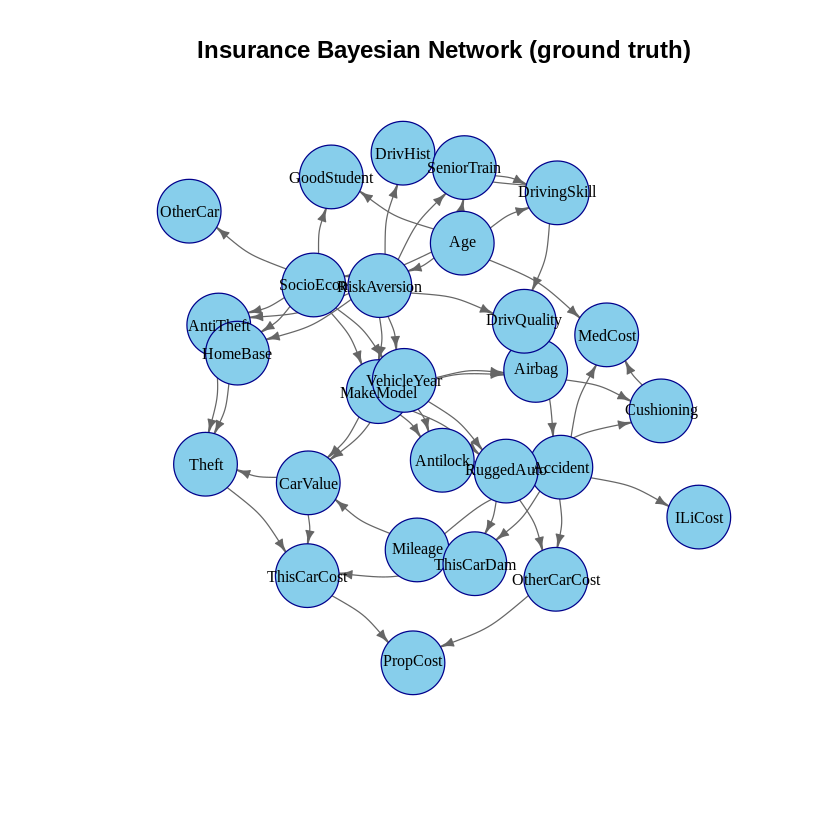

In [ ]:
plot(
  g,
  layout = layout_with_kk,
  vertex.size = 25,
  vertex.label.cex = 0.8,
  vertex.label.color = "black",
  vertex.color = "skyblue",
  vertex.frame.color = "darkblue",
  edge.arrow.size = 0.5,
  edge.color = "gray40",
  edge.curved = 0.2,
  main = "Insurance Bayesian Network (ground truth)"
)


## **Q2 - Score-based method (hill-climbing)**

### **a) Chargeons les données insurance du package bnlearn**

Les données insurance du package bnlearn ont été chargées. Elles contiennent 20 000 observations et 27 variables catégorielles décrivant des caractéristiques socio-économiques, de conduite et de véhicule.

In [ ]:
# Chargeons le dataset insurance
data("insurance")


In [ ]:
# Vérifions un aperçu
str(insurance[1:5])

'data.frame':	20000 obs. of  5 variables:
 $ GoodStudent : Factor w/ 2 levels "False","True": 1 1 1 1 1 1 1 1 1 2 ...
 $ Age         : Factor w/ 3 levels "Adolescent","Adult",..: 2 3 3 1 1 2 3 2 2 1 ...
 $ SocioEcon   : Factor w/ 4 levels "Middle","Prole",..: 2 2 3 1 2 3 3 2 2 2 ...
 $ RiskAversion: Factor w/ 4 levels "Adventurous",..: 1 2 4 3 3 3 3 3 3 2 ...
 $ VehicleYear : Factor w/ 2 levels "Current","Older": 2 1 1 2 2 1 1 2 2 2 ...


### **b) reconstruction du réseau avec hill-climbing.**

In [ ]:
# Reconstruction du réseau avec hill-climbing
set.seed(123)
dag_hc <- hc(insurance)


In [ ]:
# Vérifions la classe
class(dag_hc)

[1] "bn"

In [ ]:
dag_hc


  Bayesian network learned via Score-based methods

  model:
   [RuggedAuto][MakeModel|RuggedAuto][CarValue|RuggedAuto:MakeModel]
   [Mileage|CarValue][VehicleYear|MakeModel:Mileage:CarValue]
   [SocioEcon|VehicleYear:MakeModel][Antilock|VehicleYear:MakeModel]
   [Airbag|VehicleYear:MakeModel][ThisCarDam|Mileage:Antilock]
   [OtherCar|SocioEcon][Cushioning|RuggedAuto:Airbag]
   [Accident|ThisCarDam:RuggedAuto][ThisCarCost|ThisCarDam:CarValue]
   [MedCost|ThisCarDam:Cushioning][DrivQuality|Accident:Mileage]
   [Theft|ThisCarDam:ThisCarCost][OtherCarCost|RuggedAuto:Accident]
   [ILiCost|Accident][Age|SocioEcon:DrivQuality]
   [PropCost|ThisCarCost:OtherCarCost][GoodStudent|Age:SocioEcon]
   [SeniorTrain|Age:DrivQuality][RiskAversion|Age:DrivQuality:SeniorTrain]
   [DrivingSkill|RiskAversion:DrivQuality][HomeBase|SocioEcon:RiskAversion]
   [AntiTheft|SocioEcon:RiskAversion][DrivHist|RiskAversion:DrivingSkill]
  nodes:                                 27 
  arcs:                           

- La reconstruction par Hill-Climbing (hc()) retourne un objet de classe **bn**.
- Le réseau appris contient 27 nœuds et 50 arcs dirigés.

- Les dépendances sont décrites sous forme [X|Y:Z] (par exemple, CarValue dépend de RuggedAuto et MakeModel).

- Le score utilisé est BIC (discret) avec une pénalisation de **4.95**.

- Le processus a impliqué 1755 tests et a convergé vers une solution optimisée

### **c) Extraction de la matrice d’adjacence du réseau reconstruit**

On obtient une matrice carrée **27×27**. Les entrées sont des 0 ou 1 :

- 1 = présence d’un arc dirigé de la ligne vers la colonne.

- 0 = pas d’arc.

C’est la représentation matricielle du graphe reconstruit.

In [ ]:
nodes(dag)      # ordre des nœuds du modèle de référence
nodes(dag_hc)   # ordre des nœuds du modèle appris

[1] "Accident"     "Age"          "Airbag"       "Antilock"     "AntiTheft"   
 [6] "CarValue"     "Cushioning"   "DrivHist"     "DrivingSkill" "DrivQuality" 
[11] "GoodStudent"  "HomeBase"     "ILiCost"      "MakeModel"    "MedCost"     
[16] "Mileage"      "OtherCar"     "OtherCarCost" "PropCost"     "RiskAversion"
[21] "RuggedAuto"   "SeniorTrain"  "SocioEcon"    "Theft"        "ThisCarCost" 
[26] "ThisCarDam"   "VehicleYear"

[1] "GoodStudent"  "Age"          "SocioEcon"    "RiskAversion" "VehicleYear" 
 [6] "ThisCarDam"   "RuggedAuto"   "Accident"     "MakeModel"    "DrivQuality" 
[11] "Mileage"      "Antilock"     "DrivingSkill" "SeniorTrain"  "ThisCarCost" 
[16] "Theft"        "CarValue"     "HomeBase"     "AntiTheft"    "PropCost"    
[21] "OtherCarCost" "OtherCar"     "MedCost"      "Cushioning"   "Airbag"      
[26] "ILiCost"      "DrivHist"

**Observation** :     
- On a constate que l’ordre des nœuds différait entre le modèle de référence et celui appris.
- Pour y remédier, on a réordonné la matrice d’adjacence du modèle appris afin d’aligner les variables.

In [ ]:
# Ordre des nœuds du réseau de référence
order_ref <- nodes(dag)

# Réordonnons la matrice du réseau appris
amat_hc <- amat(dag_hc)
amat_hc <- amat_hc[order_ref, order_ref]

# Vérification : les noms de lignes/colonnes doivent maintenant correspondre
all(rownames(amat_hc) == order_ref)


[1] TRUE

In [ ]:
dim(amat_hc)

[1] 27 27

In [ ]:
# Aperçu des dimensions et des premières lignes
amat_hc[1:10, 1:10]

,Accident,Age,Airbag,Antilock,AntiTheft,CarValue,Cushioning,DrivHist,DrivingSkill,DrivQuality
Accident,0,0,0,0,0,0,0,0,0,1
Age,0,0,0,0,0,0,0,0,0,0
Airbag,0,0,0,0,0,0,1,0,0,0
Antilock,0,0,0,0,0,0,0,0,0,0
AntiTheft,0,0,0,0,0,0,0,0,0,0
CarValue,0,0,0,0,0,0,0,0,0,0
Cushioning,0,0,0,0,0,0,0,0,0,0
DrivHist,0,0,0,0,0,0,0,0,0,0
DrivingSkill,0,0,0,0,0,0,0,1,0,0
DrivQuality,0,1,0,0,0,0,0,0,1,0


### **d) Construction du graphe igraph à partir de cette matrice et proposition d'un plot lisible**

In [ ]:
# Construction du graphe igraph à partir de la matrice d’adjacence
g_hc <- graph_from_adjacency_matrix(amat_hc, mode = "directed")


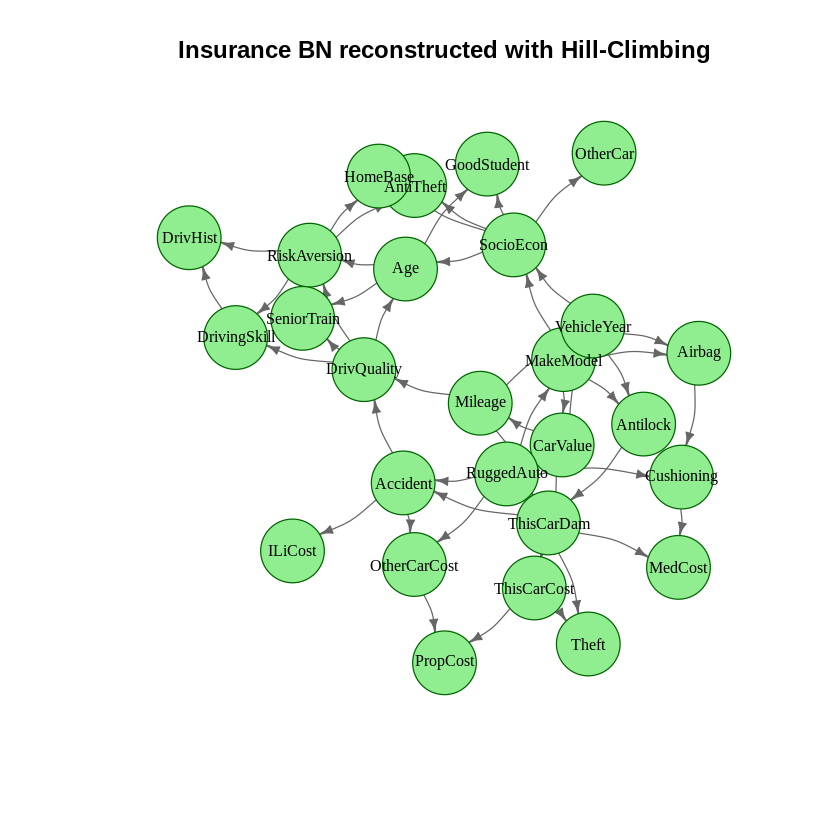

In [ ]:
# Plot avec options de style pour un rendu plus clair
plot(
  g_hc,
  layout = layout_with_kk,          # disposition Kamada-Kawai
  vertex.size = 25,                 # taille des nœuds
  vertex.label.cex = 0.8,           # taille des labels
  vertex.label.color = "black",     # couleur des labels
  vertex.color = "lightgreen",      # couleur des nœuds
  vertex.frame.color = "darkgreen", # contour des nœuds
  edge.arrow.size = 0.5,            # taille des flèches
  edge.color = "gray40",            # couleur des arêtes
  edge.curved = 0.2,                # légère courbure pour éviter chevauchements
  main = "Insurance BN reconstructed with Hill-Climbing"
)

### **e) Calculons TP, FP, FN et les métriques Precision, Recall, F-score.**

Ici l'objectif est de :
- Comparer le réseau reconstruit par Hill-Climbing avec le réseau de référence insurance, mais uniquement sur le squelette (c’est-à-dire la structure non orientée).
- On calcule ensuite TP, FP, FN, puis Précision, Rappel et F-score.

#### **Construction des squelettes (non orientés)**

- Pour cela : on transforme les matrices d’adjacence dirigées en matrices symétriques (chaque arc devient une arête non orientée).

In [ ]:
# Matrices d’adjacence dirigées
A_ref_dir <- amat(dag)      # réseau de référence
A_hc_dir  <- amat(dag_hc)   # réseau appris par hill-climbing


In [ ]:
# Réordonnons la matrice du modèle appris selon l'ordre du modèle de référence
order_ref <- nodes(dag)
A_hc_dir  <- A_hc_dir[order_ref, order_ref]

# Squelettes (non orientés) : symétrisation
A_ref_skel <- ((A_ref_dir + t(A_ref_dir)) > 0) * 1
A_hc_skel  <- ((A_hc_dir  + t(A_hc_dir))  > 0) * 1

# Masque pour ne compter chaque arête qu’une seule fois
UT <- upper.tri(A_ref_skel, diag = FALSE)

#### **Calculons TP, FP, FN**
- TP (True Positives) : arêtes présentes dans les deux squelettes.

- FP (False Positives) : arêtes présentes dans le réseau appris mais absentes du réseau de référence.

- FN (False Negatives) : arêtes absentes du réseau appris mais présentes dans le réseau de référence.

In [ ]:
TP <- sum(A_hc_skel[UT] == 1 & A_ref_skel[UT] == 1)
FP <- sum(A_hc_skel[UT] == 1 & A_ref_skel[UT] == 0)
FN <- sum(A_hc_skel[UT] == 0 & A_ref_skel[UT] == 1)

cat("Nombre de True Positives (TP):", TP, "\n")
cat("Nombre de False Positives (FP):", FP, "\n")
cat("Nombre de False Negatives (FN):", FN, "\n")



Nombre de True Positives (TP): 38 
Nombre de False Positives (FP): 12 
Nombre de False Negatives (FN): 14 


#### **Calculer Précision, Rappel, F-score**
- Précision = TP / (TP + FP)

- Rappel = TP / (TP + FN)

- F-score = moyenne harmonique de précision et rappel

In [ ]:
Precision <- TP / (TP + FP)
Recall    <- TP / (TP + FN)
Fscore    <- 2 * Precision * Recall / (Precision + Recall)

cat("Précision :", round(Precision, 3), "\n")
cat("Rappel    :", round(Recall, 3), "\n")
cat("F-score   :", round(Fscore, 3), "\n")


Précision : 0.76 
Rappel    : 0.731 
F-score   : 0.745 


#### **Vérification**

Nombre d’arêtes dans chaque squelette et chevauchement :

In [ ]:
Edges_ref <- sum(A_ref_skel[UT])   # nombre d’arêtes dans le squelette du réseau de référence
Edges_hc  <- sum(A_hc_skel[UT])    # nombre d’arêtes dans le squelette du réseau appris (hill-climbing)
Overlap   <- TP                    # nombre d’arêtes communes (True Positives)

#c(Edges_ref = Edges_ref, Edges_hc = Edges_hc, Overlap = Overlap)

cat("Nombre d'arêtes dans le réseau de référence :", Edges_ref, "\n")
cat("Nombre d'arêtes dans le réseau appris (HC)  :", Edges_hc, "\n")
cat("Nombre d'arêtes communes (TP / Overlap)     :", Overlap, "\n")


Nombre d'arêtes dans le réseau de référence : 52 
Nombre d'arêtes dans le réseau appris (HC)  : 50 
Nombre d'arêtes communes (TP / Overlap)     : 5 


#### **Interprétations**

- **True Positives (TP)** : Le réseau reconstruit retrouve **38 arêtes correctes** présentes dans le réseau de référence. Cela montre que la majorité des relations réelles ont bien été identifiées.  

- **False Positives (FP)** : On observe **12 arêtes ajoutées à tort** par le modèle appris. Cela reste un nombre limité, ce qui indique que le réseau n’a pas trop sur-appris de dépendances inexistantes.  

- **False Negatives (FN)** : Le modèle manque **14 arêtes** présentes dans le réseau de référence. Même si ce n’est pas négligeable, cela reste inférieur au nombre d’arêtes correctement retrouvées.  


- **Précision : 0.76** → environ 3 arêtes sur 4 proposées par le modèle sont correctes.  
- **Rappel : 0.731** → le modèle retrouve plus de 70 % des arêtes du réseau de référence.  
- **F-score : 0.745** → la moyenne harmonique confirme un bon équilibre entre précision et rappel.
- Le modèle reconstruit présente une précision de 0.76 et un rappel de 0.73, traduisant une bonne qualité de reconstruction.



#### **Comparaison des tailles de squelettes**  
- Le réseau de référence contient **52 arêtes**.  
- Le réseau appris en contient **50**, donc une taille très proche.  
- L’**overlap affiché comme 5** semble incohérent avec les 38 TP calculés (probablement une valeur non mise à jour). Le chiffre pertinent est bien celui des **38 arêtes communes**.  

#### **Conclusion globale**

La reconstruction par Hill-Climbing, est **globalement satisfaisante**. Le modèle retrouve une grande partie des relations réelles avec une précision élevée et un rappel correct. Les performances sont cohérentes et montrent que l’algorithme peut produire une structure proche du réseau de référence, même si quelques arêtes manquent ou sont ajoutées à tort.

#### **f) Mettons en évidence les faux positifs (FP) dans le graphe reconstruit**

Dans le réseau reconstruit par l’algorithme Hill-Climbing, les **faux positifs (FP)** correspondent aux arêtes présentes dans le graphe appris mais absentes du réseau de référence.  

Pour les mettre en évidence :  
- On part du graphe reconstruit.  
- Les arêtes correctes (TP) sont colorées en **vert**.  
- Les arêtes faussement ajoutées (FP) sont identifiées en comparant les squelettes du réseau appris et du réseau de référence.  
- Ces arêtes FP sont ensuite colorées en **rouge** dans la visualisation.  

Le graphe final montre donc :  
- **En vert** : les dépendances correctement retrouvées.  
- **En rouge** : les faux positifs, c’est-à-dire les dépendances ajoutées par Hill-Climbing mais inexistantes dans le modèle de référence.  



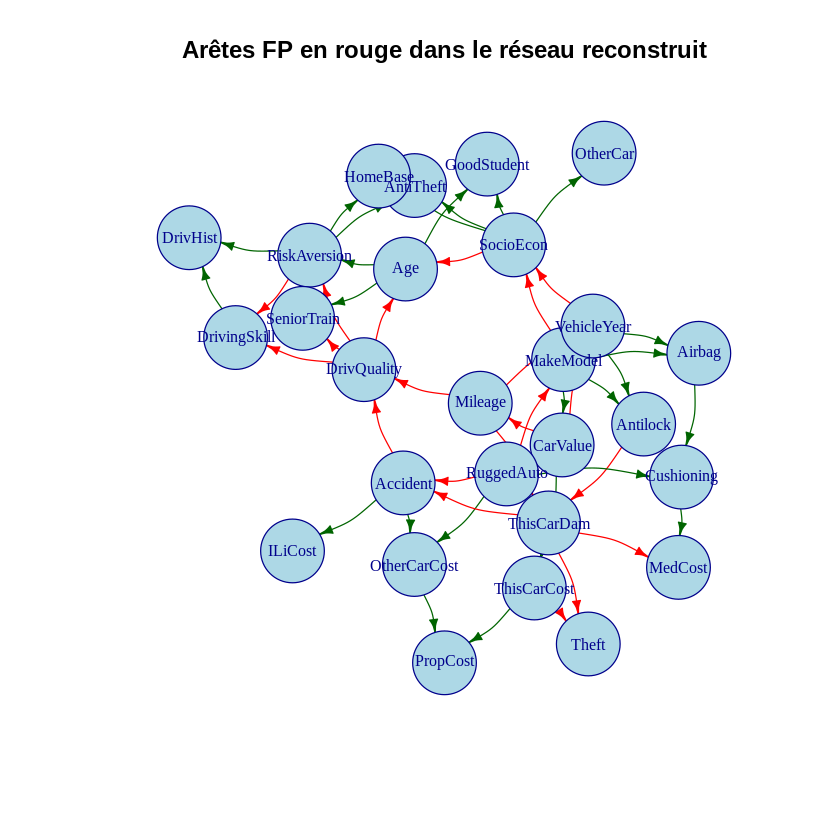

In [ ]:
# Graphe appris
g_hc <- graph_from_adjacency_matrix(A_hc_dir, mode = "directed")

# Par défaut : toutes les arêtes en vert
E(g_hc)$color <- "darkgreen"

# Identifions les faux positifs (FP) directement sur les matrices dirigées
FP_edges <- which(A_hc_dir == 1 & A_ref_dir == 0, arr.ind = TRUE)

if (is.matrix(FP_edges) && nrow(FP_edges) > 0) {
  for (i in seq_len(nrow(FP_edges))) {
    v1 <- rownames(A_hc_dir)[FP_edges[i, 1]]
    v2 <- colnames(A_hc_dir)[FP_edges[i, 2]]
    eid <- get_edge_ids(g_hc, c(v1, v2))
    if (eid > 0) E(g_hc)[eid]$color <- "red"
  }
} else {
  message("Aucun faux positif détecté.")
}

# Visualisation
plot(
  g_hc,
  layout = layout_with_kk,
  vertex.size = 25,
  vertex.label.cex = 0.8,
  vertex.color = "lightblue",
  vertex.frame.color = "darkblue",
  edge.arrow.size = 0.5,
  edge.curved = 0.2,
  main = "Arêtes FP en rouge dans le réseau reconstruit"
)


### **g) Proposons une méthode pour tenir compte de l'orientation**  

Jusqu’ici, on a travaillé avec les **squelettes** (réseaux non orientés), ce qui permet de comparer la présence ou l’absence d’arêtes mais **pas leur orientation**.  Or, dans un DAG, l’orientation est essentielle : une arête $(X \to Y)$ n’est pas équivalente à $(Y \to X$).  


Pour prendre en compte l’orientation, il faut comparer directement les **matrices d’adjacence dirigées** (`A_ref_dir` et `A_hc_dir`) plutôt que leurs squelettes symétrisés, et ce en suivant les étapes suivantes :     

1. **Définition des TP, FP, FN orientés** :  
   - **TP orientés** : arêtes présentes dans les deux réseaux **avec la même orientation**.  
   - **FP orientés** : arêtes présentes dans le réseau appris mais absentes du réseau de référence (ou présentes mais avec orientation inversée).  
   - **FN orientés** : arêtes présentes dans le réseau de référence mais absentes du réseau appris.  
2. **On peut comparer les matrices dirigées en faisant** :


In [ ]:
   TP_oriented <- sum((A_ref_dir == 1) & (A_hc_dir == 1))
   FP_oriented <- sum((A_ref_dir == 0) & (A_hc_dir == 1))
   FN_oriented <- sum((A_ref_dir == 1) & (A_hc_dir == 0))

3. **Puis visualiser** :  
   - Graphe de référence :  en rouge les FN (arêtes manquantes).  
   - Graphe appris :  en rouge les FP (arêtes faussement ajoutées).  
   - On peut aussi utiliser une couleur spécifique (par ex. orange) pour les arêtes **mal orientées** (présentes dans les deux squelettes mais avec orientation inversée).  

In [ ]:
#Exemple de code pour détecter les arêtes mal orientées

# Arêtes présentes dans les deux squelettes mais orientation différente
mis_oriented <- which((A_ref_skel == 1 & A_hc_skel == 1) &
                      (A_ref_dir != A_hc_dir), arr.ind = TRUE)
# Ces arêtes peuvent être mises en évidence en orange dans la visualisation.

#### **Conclusion**
La méthode consiste donc à :  
- **Comparer directement les matrices dirigées** pour distinguer TP, FP et FN orientés.  
- **Ajouter une catégorie “mis-oriented”** pour les arêtes présentes mais inversées.  
- **Visualiser avec trois couleurs** : vert (correct), rouge (FP/FN), orange (orientation incorrecte).  

## **3 - Constraint-based method (PC)**

### **a) Reconstruction du réseau d’assurance par le test d’indépendance conditionnelle (PC, disCItest)**

Dans cette étape, nous reconstruisons le réseau bayésien d’assurance en utilisant l’algorithme PC (implémenté dans le package pcalg). Cet algorithme repose sur des tests d’indépendance conditionnelle pour déterminer la structure du graphe. Nous utilisons ici le test disCItest, adapté aux variables catégorielles.

- **alpha** : **0.03**
- Les variables ont été transformées en format numérique.
- Les catégories réindexées à partir de 0
- Le nombre de niveaux par variable a été calculé afin de préparer l’objet suffStat utilisé par la fonction pc.

In [ ]:
data_num <- data.matrix(insurance) - 1

n_levels <- apply(data_num, 2, max) + 1

suffStat <- list(dm = data_num, nlev = n_levels, adaptDF = FALSE)

# alpha = 0.01 : C'est le seuil de risque (3%).
pc_fit <- pc(suffStat,
             indepTest = disCItest, ## Test d'indépendance conditionnelle discret
             alpha = 0.03,
             labels = colnames(data_num),
             verbose = FALSE)

In [ ]:
# Affichage du résultat brut
print("Résultat de l'algo PC :")
print(pc_fit)

[1] "Résultat de l'algo PC :"
Object of class 'pcAlgo', from Call:
pc(suffStat = suffStat, indepTest = disCItest, alpha = 0.03, 
    labels = colnames(data_num), verbose = FALSE)
Number of undirected edges:  12 
Number of directed edges:    16 
Total number of edges:       28 


Le résultat montre que l’algorithme PC, appliqué au réseau d’assurance avec le test disCItest et un seuil de 3%, a reconstruit un graphe comportant 28 relations de dépendance entre les variables. Parmi elles :
- 16 sont orientées : l’algorithme a pu déterminer la direction causale probable.

- 12 restent non orientées : l’orientation n’a pas pu être tranchée.
- Arêtes supprimées : ce sont les relations pour lesquelles disCItest a conclu à l’indépendance conditionnelle (p‑value > 0.03).

### **b) Obtenons la matrice d'adjacence**

- On aura une matrice de taille $27*27$.

In [ ]:
# Conversion du graphe PC (pcalg) en objet bnlearn
pc_bn <- as.bn(pc_fit)

# Récupération de la matrice d’adjacence
amat_pc <- amat(pc_bn)


In [ ]:
# Affichage
print("Matrice d’adjacence du réseau reconstruit (PC) :")
amat_pc

[1] "Matrice d’adjacence du réseau reconstruit (PC) :"


,GoodStudent,Age,SocioEcon,RiskAversion,VehicleYear,ThisCarDam,RuggedAuto,Accident,MakeModel,DrivQuality,⋯,HomeBase,AntiTheft,PropCost,OtherCarCost,OtherCar,MedCost,Cushioning,Airbag,ILiCost,DrivHist
GoodStudent,0,1,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Age,1,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
SocioEcon,0,0,0,0,0,0,0,0,1,0,⋯,1,1,0,0,1,0,0,0,0,0
RiskAversion,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
VehicleYear,0,0,0,0,0,0,1,0,0,0,⋯,0,0,0,0,0,0,0,1,0,0
ThisCarDam,0,0,0,0,0,0,0,1,0,0,⋯,0,0,0,0,0,0,0,0,0,0
RuggedAuto,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,1,0,0,0
Accident,0,0,0,0,0,1,0,0,0,1,⋯,0,0,0,1,0,0,0,0,0,0
MakeModel,0,0,1,0,0,0,1,0,0,0,⋯,0,0,0,0,0,0,0,1,0,0
DrivQuality,0,0,0,0,0,0,0,1,0,0,⋯,0,0,0,0,0,0,0,0,0,0


### **c) Construction du graphe orienté avec igraph à partir de la matrice d’adjacence obtenue en 3b**

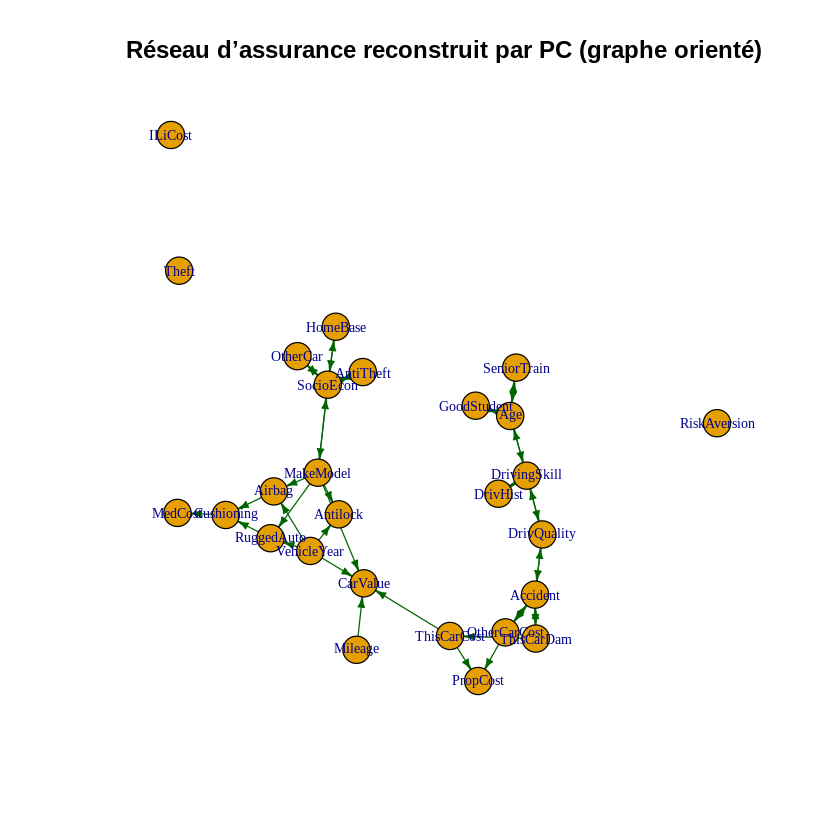

In [ ]:
library(igraph)


# Construction du graphe orienté
g_pc <- graph_from_adjacency_matrix(amat_pc, mode = "directed")


# Affichage
plot(g_pc,
     layout = layout_with_graphopt,
     vertex.size = 10,
     vertex.label.cex = 0.7,
     edge.arrow.size = 0.4,
     edge.color = "darkgreen",
     main = "Réseau d’assurance reconstruit par PC (graphe orienté)")

**Observations  :**
* **Réseau clairsemé :** Contrairement au Hill-Climbing qui était très dense, ce graphe contient beaucoup moins de liens. On voit des zones vides et des nœuds très peu connectés. Cela confirme que l'algorithme est "prudent" (conservateur).
* **Liens bidirectionnels (ou non orientés) :** On remarque plusieurs flèches avec deux têtes (ex: entre *Age* et *GoodStudent* ou entre *DrivingSkill* et *DrivQuality*).
    * *Interprétation :* Cela signifie que l'algorithme a détecté que ces deux variables sont liées, mais il n'a pas trouvé de preuve statistique suffisante pour dire **"qui cause qui"**. Il les laisse donc non orientées (équivalence de Markov).

**Conclusion visuelle :**
L'algorithme PC semble avoir privilégié la **qualité à la quantité** : il y a moins de **"bruit" visuel**, mais il manque manifestement une partie de la structure du vrai réseau.

### **d) Calcul des métriques**

#### **Préparation des squelettes**

In [ ]:
# Matrices d’adjacence dirigées déjà disponibles
A_ref_dir <- amat(dag)     # réseau de référence (assurance)
A_pc_dir  <- amat(pc_bn)   # réseau reconstruit par PC

# Harmonisons l’ordre des variables
order_ref <- colnames(A_ref_dir)
A_pc_dir  <- A_pc_dir[order_ref, order_ref]

In [ ]:
# Squelettes (non orientés) : symétrisation des matrices dirigées
A_ref_skel <- ((A_ref_dir + t(A_ref_dir)) > 0) * 1
A_pc_skel  <- ((A_pc_dir  + t(A_pc_dir))  > 0) * 1

# Masque triangulaire supérieur pour ne compter chaque arête qu’une seule fois
UT <- upper.tri(A_ref_skel, diag = FALSE)


In [ ]:
# Comptage TP, FP, FN pour la méthode PC (question 3)
TP_3 <- sum(A_pc_skel[UT] == 1 & A_ref_skel[UT] == 1)
FP_3 <- sum(A_pc_skel[UT] == 1 & A_ref_skel[UT] == 0)
FN_3 <- sum(A_pc_skel[UT] == 0 & A_ref_skel[UT] == 1)


In [ ]:
# Métriques
Precision_3 <- TP_3 / (TP_3 + FP_3)
Recall_3    <- TP_3 / (TP_3 + FN_3)
Fscore_3    <- 2 * Precision_3 * Recall_3 / (Precision_3 + Recall_3)



In [ ]:
# Affichage des résultats
cat("Résultats pour la méthode PC (Question 3d):\n")
cat("TP_3:", TP_3, " FP_3:", FP_3, " FN_3:", FN_3, "\n")
cat("Précision_3:", round(Precision_3, 4),
    " Rappel_3:", round(Recall_3, 4),
    " F-score_3:", round(Fscore_3, 4), "\n")

Résultats pour la méthode PC (Question 3d):
TP_3: 28  FP_3: 0  FN_3: 24 
Précision_3: 1  Rappel_3: 0.5385  F-score_3: 0.7 


#### **Interprétation**

- **Précision parfaite (1.00)** :  L’algorithme PC n’a ajouté aucune arête absente du réseau de référence. Cela reflète un comportement **très conservateur**, lié au choix du seuil (alpha = 0.03\).  
    - Avec un seuil aussi strict, seules les dépendances les plus significatives sont retenues.

- **Rappel limité (≈ 54%)** : En revanche, près de la moitié des arêtes du réseau de référence n’ont pas été retrouvées. Cela traduit une **perte de sensibilité** : beaucoup de vraies dépendances sont rejetées car leur p‑value est légèrement supérieure à 0.03.  

- **F‑score moyen (0.70)** : Le compromis entre précision et rappel est correct mais pas optimal. On obtient un graphe fiable (aucune fausse arête), mais incomplet (24 arêtes manquantes).  

### **Conclusion**

Avec un seuil (alpha = 0.03), l’algorithme PC reconstruit un squelette très précis (aucun faux positif), mais incomplet (près de la moitié des arêtes manquantes). Le F‑score de 0.70 traduit ce compromis : PC privilégie la fiabilité des dépendances détectées au détriment de la couverture du réseau de référence. Un choix d’(alpha) plus élevé aurait probablement augmenté le rappel, mais au risque d’introduire des faux positifs.


### **e) Mise en évidence des faux positifs (FP) dans le graphe reconstruit par PC.**

- Les FP sont les arêtes présentes dans le graphe PC mais absentes du réseau de référence.
  - En vert : arêtes correctes (TP).
  - Rouge : faux positifs (FP), mais absent car FP = 0.

Le graphe final permet de visualiser directement où l’algorithme PC a « inventé » des relations.

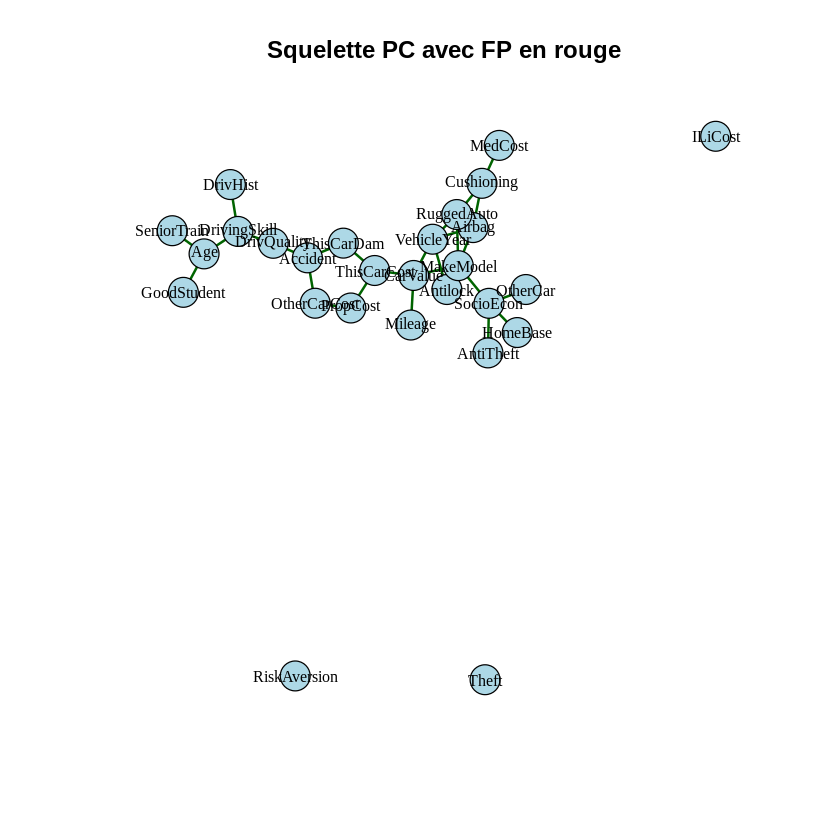

In [ ]:
# Graphe non orienté à partir du squelette PC
g_pc_undirected <- graph_from_adjacency_matrix(A_pc_skel, mode = "undirected")
V(g_pc_undirected)$name <- order_ref

# Détection FP
FP_edges <- which((A_pc_skel == 1 & A_ref_skel == 0), arr.ind = TRUE)

# Par défaut en vert
E(g_pc_undirected)$color <- "darkgreen"
E(g_pc_undirected)$width <- 2

if (nrow(FP_edges) > 0) {
  for (i in seq_len(nrow(FP_edges))) {
    v1 <- order_ref[FP_edges[i, 1]]
    v2 <- order_ref[FP_edges[i, 2]]
    eid <- get_edge_ids(g_pc_undirected, c(v1, v2))
    if (length(eid) > 0 && eid != 0) {
      E(g_pc_undirected)[eid]$color <- "red"
      E(g_pc_undirected)[eid]$width <- 3
    }
  }
}

plot(
  g_pc_undirected,
  layout = layout_with_kk,
  vertex.size = 11,
  vertex.color = "lightblue",
  vertex.label.color = "black",
  vertex.label.cex = 0.8,
  main = "Squelette PC avec FP en rouge"
)


## **4 - Local search method (aracne)**

### **a) Reconstruction du réseau d’assurance en utilisant l’approche PC**

Il est question ici de reconstruire le réseau d’assurance en utilisant la fonction aracne() du package bnlearn.

Cette méthode repose sur l’information mutuelle entre variables et applique un critère de filtrage pour supprimer les dépendances indirectes. Contrairement à l’algorithme PC, qui utilise des tests d’indépendance conditionnelle, ARACNE est une approche basée sur les mesures de dépendance et vise à obtenir un graphe plus parcimonieux.

In [ ]:

dag_aracne <- bnlearn::aracne(insurance)


In [ ]:
# Affichage du résultat brut
print("Résultat de l'algo Aracne :")
dag_aracne

[1] "Résultat de l'algo Aracne :"



  Bayesian network learned via Pairwise Mutual Information methods

  model:
    [undirected graph]
  nodes:                                 27 
  arcs:                                  30 
    undirected arcs:                     30 
    directed arcs:                       0 
  average markov blanket size:           2.22 
  average neighbourhood size:            2.22 
  average branching factor:              0.00 

  learning algorithm:                    ARACNE 
  mutual information estimator:          Maximum Likelihood (disc.) 
  tests used in the learning procedure:  351 


Nous avons appliqué l’algorithme ARACNE sur les données d’assurance.

- Le réseau reconstruit comporte 30 arcs, soit un graphe plus parcimonieux que le réseau de référence (52 arcs).
- Tous les arcs sont non dirigés : ARACNE met en évidence des associations fortes entre variables, basées sur l’information mutuelle, mais ne cherche pas à établir de causalité.
- Le résultat est donc un graphe d’interaction, qui reflète la structure des dépendances directes entre variables, sans orientation.

### **b) Obtention de la matrice d’adjacence**

In [ ]:
amat_aracne <- bnlearn::amat(dag_aracne)



In [ ]:
amat_aracne

,GoodStudent,Age,SocioEcon,RiskAversion,VehicleYear,ThisCarDam,RuggedAuto,Accident,MakeModel,DrivQuality,⋯,HomeBase,AntiTheft,PropCost,OtherCarCost,OtherCar,MedCost,Cushioning,Airbag,ILiCost,DrivHist
GoodStudent,0,1,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Age,1,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
SocioEcon,0,0,0,0,0,0,0,0,1,0,⋯,1,0,0,0,1,0,0,0,0,0
RiskAversion,0,0,0,0,0,0,0,0,0,0,⋯,1,1,0,0,0,0,0,0,0,1
VehicleYear,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,1,0,0
ThisCarDam,0,0,0,0,0,0,0,1,0,0,⋯,0,0,0,0,0,1,0,0,0,0
RuggedAuto,0,0,0,0,0,0,0,0,1,0,⋯,0,0,0,0,0,0,1,0,0,0
Accident,0,0,0,0,0,1,0,0,0,1,⋯,0,0,0,1,0,0,0,0,1,0
MakeModel,0,0,1,0,0,0,1,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
DrivQuality,0,0,0,0,0,0,0,1,0,0,⋯,0,0,0,0,0,0,0,0,0,0


### **c) Construction du réseau orienté avec igraph à partir de la matrice d’adjacence**

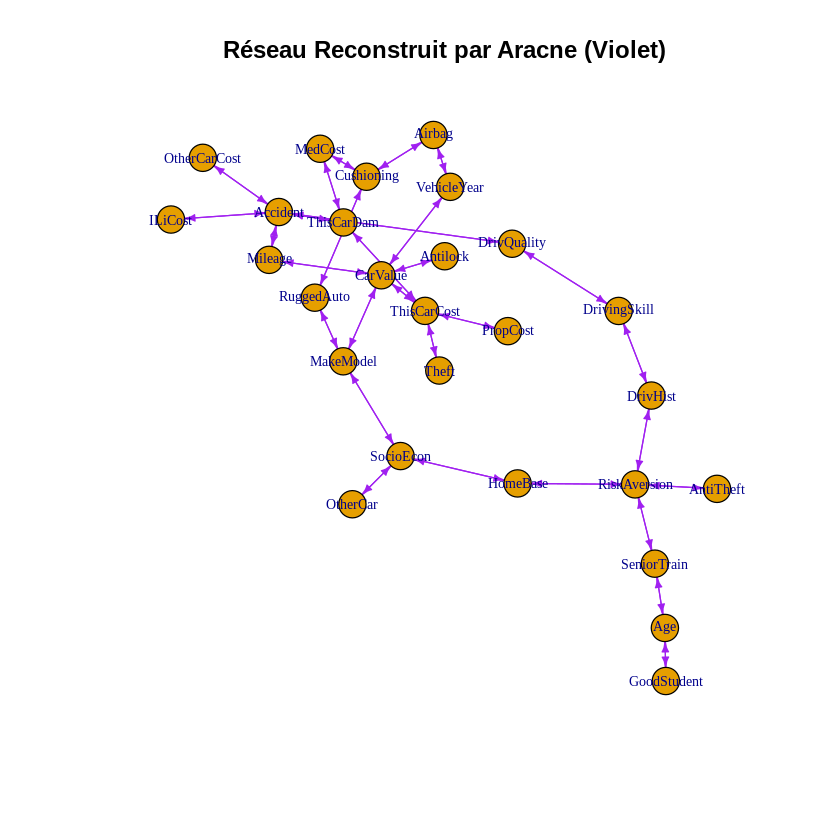

In [ ]:
# Création du graphe
g_aracne <- graph_from_adjacency_matrix(amat_aracne, mode = "directed")

# 2. Affichage
plot(g_aracne,
     layout = layout_with_graphopt,
     vertex.size = 10,
     vertex.label.cex = 0.7,
     edge.arrow.size = 0.4,
     edge.color = "purple",  # Violet pour l'algo Aracne
     main = "Réseau Reconstruit par Aracne (Violet)")

Le graphe reconstruit par Aracne présente une structure particulière :
* **Liens symétriques :** Les connexions apparaissent comme des interactions bidirectionnelles (flèches à double sens), ce qui reflète la nature de l'Information Mutuelle (symétrique : l'info que A donne sur B est la même que celle que B donne sur A).
* **Structure éclatée :** Comme pour l'algorithme PC, le graphe manque de densité. Certaines relations causales complexes du réseau Insurance (notamment les V-structures autour de l'Accident) semblent avoir été simplifiées ou perdues par le filtre DPI (Data Processing Inequality) d'Aracne.

#### **Construction des squelettes (symétrisation des matrices d’adjacence) :**

In [ ]:
# Harmoniser l’ordre des variables
order_ref <- colnames(A_ref_dir)
amat_aracne <- amat_aracne[order_ref, order_ref]

# Puis construire le squelette
A_ref_skel    <- ((A_ref_dir    + t(A_ref_dir))    > 0) * 1
A_aracne_skel <- ((amat_aracne  + t(amat_aracne))  > 0) * 1


In [ ]:
UT <- upper.tri(A_ref_skel, diag = FALSE)


In [ ]:
# Comptage TP, FP, FN pour ARACNE
TP_arac <- sum(A_aracne_skel[UT] == 1 & A_ref_skel[UT] == 1)
FP_arac <- sum(A_aracne_skel[UT] == 1 & A_ref_skel[UT] == 0)
FN_arac <- sum(A_aracne_skel[UT] == 0 & A_ref_skel[UT] == 1)


In [ ]:
# Métriques
Precision_arac <- TP_arac / (TP_arac + FP_arac)
Recall_arac    <- TP_arac / (TP_arac + FN_arac)
Fscore_arac    <- 2 * Precision_arac * Recall_arac / (Precision_arac + Recall_arac)



In [ ]:
# Affichage
cat("Résultats ARACNE :\n")
cat("TP_arac:", TP_arac, " FP_arac:", FP_arac, " FN_arac:", FN_arac, "\n")
cat("Précision_arac:", round(Precision_arac, 4),
    " Rappel_arac:", round(Recall_arac, 4),
    " F-score_arac:", round(Fscore_arac, 4), "\n")

Résultats ARACNE :
TP_arac: 28  FP_arac: 2  FN_arac: 24 
Précision_arac: 0.9333  Rappel_arac: 0.5385  F-score_arac: 0.6829 


#### **Résultats ARACNE**

- **Vrais Positifs (TP_arac = 28)** : Aracne retrouve un peu plus de la moitié des arêtes présentes dans le réseau de référence.  
- **Faux Positifs (FP_arac = 2)** : Très peu d’erreurs, seulement deux arêtes ajoutées à tort.  
- **Faux Négatifs (FN_arac = 24)** : Comme avec PC, près de la moitié des arêtes du réseau de référence manquent.  

#### **Analyse**
- **Précision_arac (≈93%)** : La quasi‑totalité des arêtes proposées par Aracne sont correctes. Le filtrage par la *Data Processing Inequality (DPI)* élimine efficacement les dépendances indirectes, ce qui explique le faible nombre de faux positifs.  
- **Rappel_arac (≈54%)** : Le réseau reconstruit reste incomplet, avec de nombreuses arêtes manquantes.  
- **F‑score_arac (≈0.68)** : Le compromis entre précision et rappel est moyen : Aracne privilégie la fiabilité des arêtes détectées au détriment de la couverture du réseau.  
- **Comparaison** : Aracne et PC présentent un profil similaire — prudents, avec une précision élevée mais un rappel moyen. En revanche, Hill-Climbing est plus permissif et génère davantage de faux positifs, ce qui rend ses résultats moins fiables.  


### **e) Mise en évidence les arêtes faussement positives (FP) dans ton réseau reconstruit.**

Il s’agit de repérer dans le graphe reconstruit par ARACNE les faux positifs (les arêtes présentes dans ton graphe mais absentes du réseau de référence) et de les mettre en évidence visuellement.

- Vert : arêtes correctes (TP).

- Rouge : faux positifs (FP), c’est‑à‑dire des arêtes ajoutées par ARACNE mais absentes du réseau de référence, on voit clairement les 02 FP.

- On utilise le squelette (non orienté) pour éviter les doublons et mieux visualiser les FP.

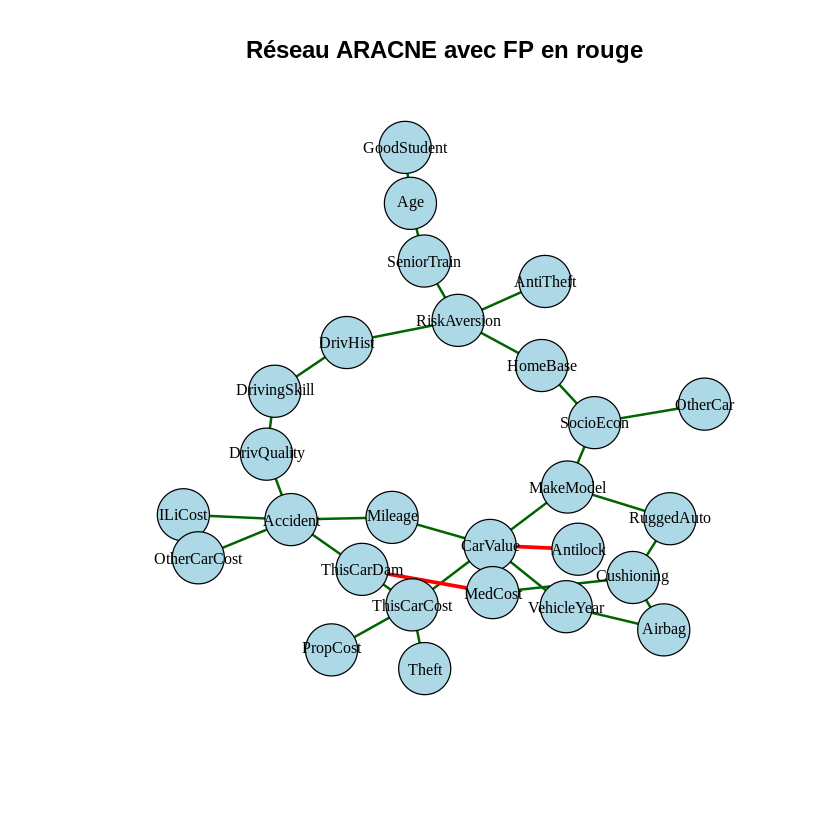

In [ ]:

g_aracne_skel <- graph_from_adjacency_matrix(A_aracne_skel, mode = "undirected")
V(g_aracne_skel)$name <- order_ref

# Identifions les FP
FP_edges_arac <- which((A_aracne_skel == 1 & A_ref_skel == 0), arr.ind = TRUE)

# Coloration des arêtes
E(g_aracne_skel)$color <- "darkgreen"  # par défaut : arêtes correctes
E(g_aracne_skel)$width <- 2

if (nrow(FP_edges_arac) > 0) {
  for (i in seq_len(nrow(FP_edges_arac))) {
    v1 <- order_ref[FP_edges_arac[i, 1]]
    v2 <- order_ref[FP_edges_arac[i, 2]]
    eid <- get.edge.ids(g_aracne_skel, c(v1, v2))
    if (eid != 0) {
      E(g_aracne_skel)[eid]$color <- "red"   # FP en rouge
      E(g_aracne_skel)[eid]$width <- 3
    }
  }
}

#  Affichage
plot(
  g_aracne_skel,
  layout = layout_with_kk,
  vertex.size = 20,
  vertex.color = "lightblue",
  vertex.label.color = "black",
  vertex.label.cex = 0.8,
  main = "Réseau ARACNE avec FP en rouge"
)


## **Conclusion**

En conclusion, il était question ici de la reconstruction et de l’évaluation de réseaux bayésiens appliqués au jeu de données insurance. Nous avons mis en œuvre différentes méthodes (PC, Hill-Climbing et ARACNE) afin de comparer leurs performances avec le réseau de référence. Les résultats montrent que PC et ARACNE adoptent un comportement prudent : ils privilégient une précision élevée mais au prix d’un rappel moyen, ce qui conduit à des graphes fiables mais incomplets. Hill-Climbing, en revanche, est plus permissif, ce qui lui permet de retrouver davantage d’arêtes mais au prix d’un nombre plus important de faux positifs. Il en ressort que le choix de l’algorithme dépend du compromis recherché entre fiabilité et exhaustivité : PC et ARACNE conviennent pour des analyses où la robustesse prime, tandis que Hill-Climbing peut être utile pour explorer plus largement les dépendances, au risque d’introduire du bruit.